In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
df = pd.read_csv("../dataset/weatherHistory.csv")

In [4]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 8.8 MB


In [6]:
df.shape

(96453, 12)

In [7]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.drop_duplicates(inplace=True)

In [11]:
df['Formatted Date'] = pd.to_datetime(
    df['Formatted Date'],
    utc=True
)

In [12]:
df['Year'] = df['Formatted Date'].dt.year

In [13]:
df['Month'] = df['Formatted Date'].dt.month

In [14]:
df['Day'] = df['Formatted Date'].dt.day

In [15]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006,3,31
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006,3,31
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006,4,1
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006,4,1
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006,4,1


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   Formatted Date            95912 non-null  datetime64[us, UTC]
 1   Summary                   95912 non-null  str                
 2   Precip Type               95912 non-null  str                
 3   Temperature (C)           95912 non-null  float64            
 4   Apparent Temperature (C)  95912 non-null  float64            
 5   Humidity                  95912 non-null  float64            
 6   Wind Speed (km/h)         95912 non-null  float64            
 7   Wind Bearing (degrees)    95912 non-null  float64            
 8   Visibility (km)           95912 non-null  float64            
 9   Loud Cover                95912 non-null  float64            
 10  Pressure (millibars)      95912 non-null  float64            
 11  Daily Summary             95912

In [17]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Year,Month,Day
count,95912.000000,95912.000000,95912.000000,95912.000000,95912.000000,95912.000000,95912.0,95912.000000,95912.000000,95912.000000,95912.000000
mean,11.937975,10.859194,0.734844,10.806764,187.506986,10.362306,0.0,1003.146959,2010.979554,6.511792,15.704823
std,9.569620,10.716711,0.195717,6.920504,107.378309,4.174204,0.0,117.291484,3.155315,3.449894,8.798292
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2005.000000,1.000000,1.000000
25%,4.594444,2.272222,0.600000,5.812100,116.000000,8.355900,0.0,1011.890000,2008.000000,4.000000,8.000000
50%,12.022222,12.022222,0.780000,9.933700,180.000000,10.046400,0.0,1016.420000,2011.000000,7.000000,16.000000
75%,18.844444,18.844444,0.890000,14.135800,290.000000,14.812000,0.0,1021.050000,2014.000000,9.000000,23.000000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000,2016.000000,12.000000,31.000000


In [18]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006,3,31
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006,3,31
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006,4,1
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006,4,1
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006,4,1


In [19]:
df.isnull().sum()

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
Year                        0
Month                       0
Day                         0
dtype: int64

In [20]:
df.dropna(inplace=True)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df['Temperature (C)'].mean()

np.float64(11.937974914504961)

In [23]:
df['Temperature (C)'].max()

np.float64(39.90555555555555)

In [24]:
df['Temperature (C)'].min()

np.float64(-21.822222222222223)

In [25]:
df['Humidity'].mean()

np.float64(0.7348440236883809)

In [26]:
df['Wind Speed (km/h)'].mean()

np.float64(10.806764096254899)

In [27]:
df['Pressure (millibars)'].mean()

np.float64(1003.1469589832348)

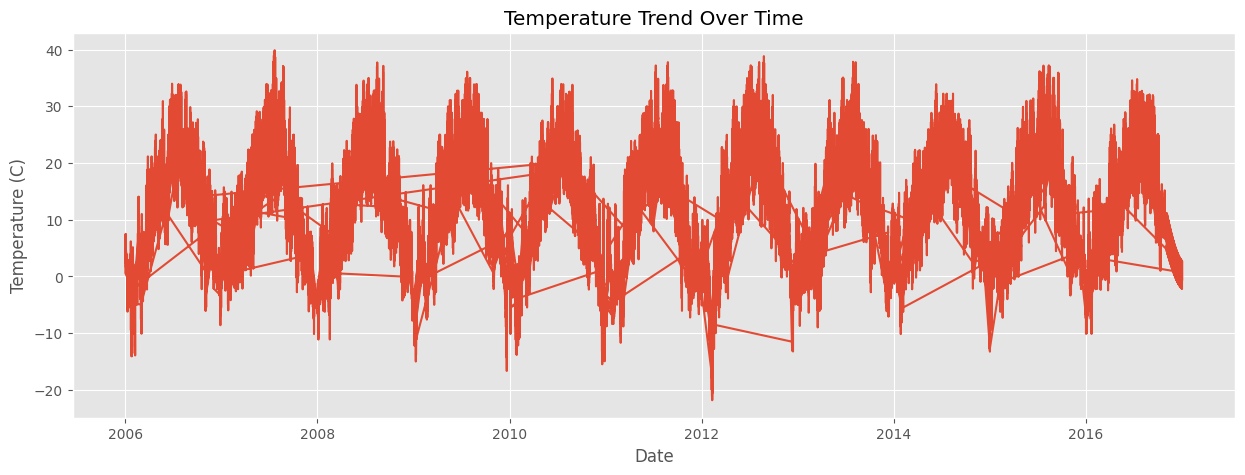

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    df['Formatted Date'],
    df['Temperature (C)']
)

plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")

plt.show()

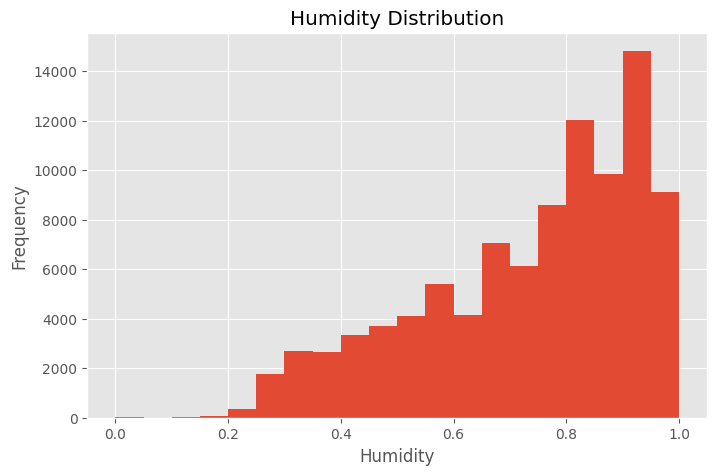

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Humidity'],
    bins=20
)

plt.title("Humidity Distribution")
plt.xlabel("Humidity")
plt.ylabel("Frequency")

plt.show()

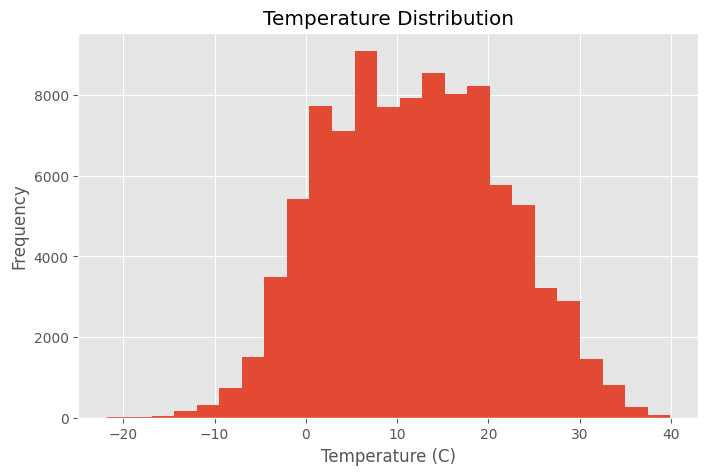

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Temperature (C)'],
    bins=25
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (C)")
plt.ylabel("Frequency")

plt.show()

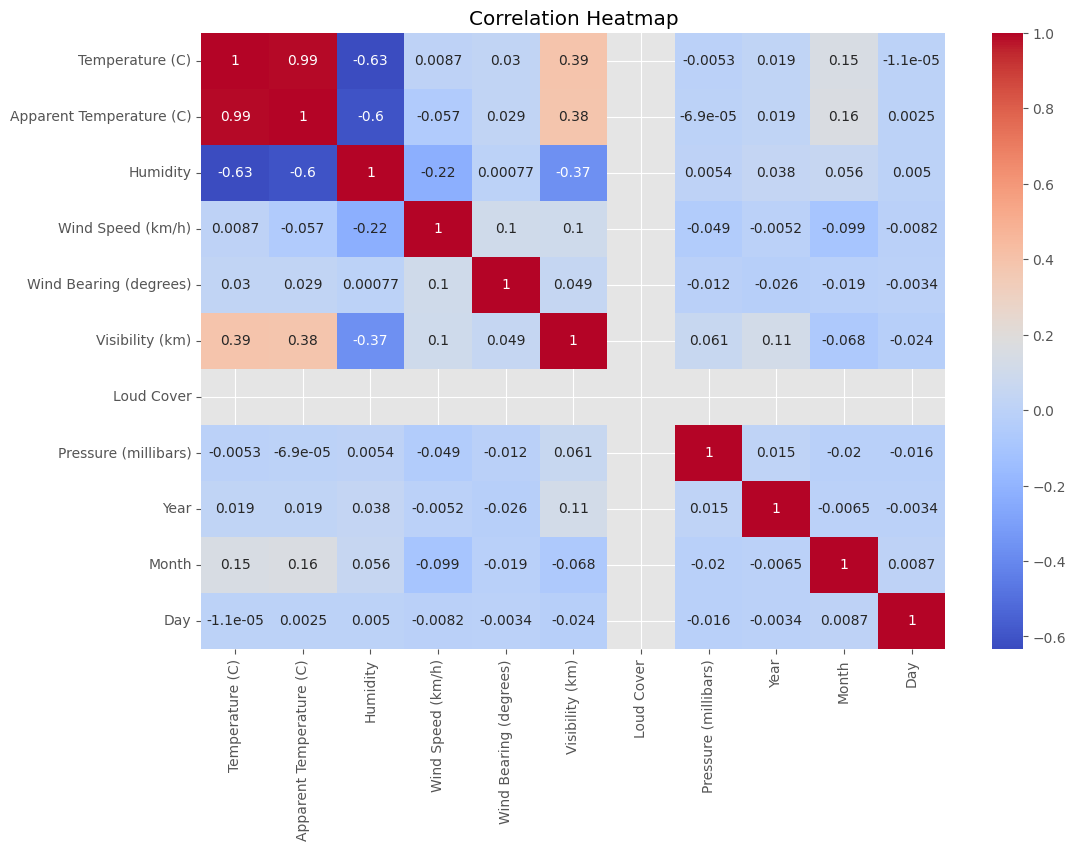

In [31]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

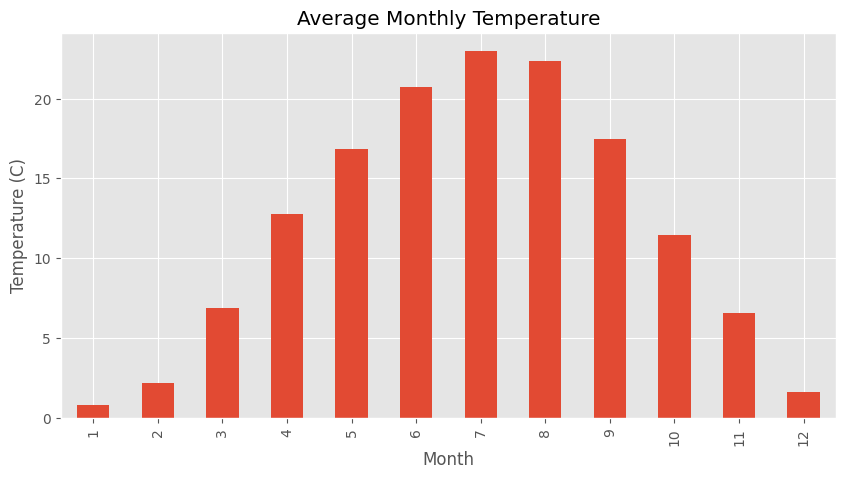

In [32]:
monthly_temp = df.groupby('Month')[
    'Temperature (C)'
].mean()

monthly_temp.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (C)")

plt.show()

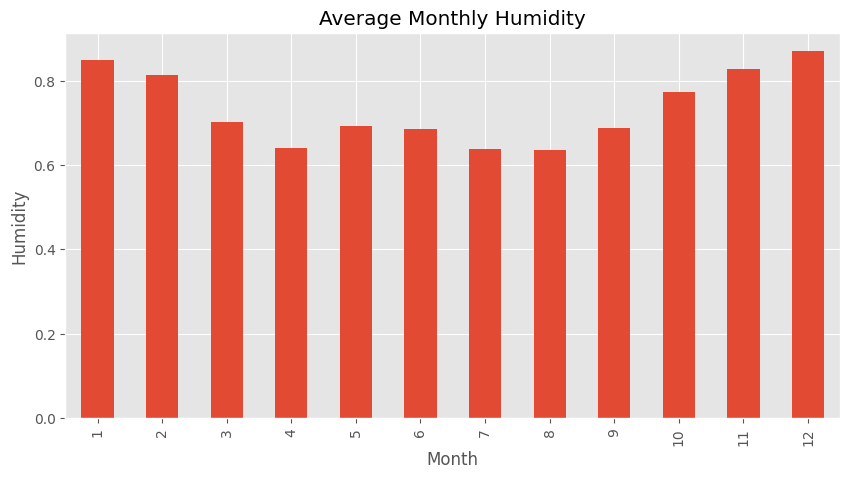

In [33]:
monthly_humidity = df.groupby('Month')[
    'Humidity'
].mean()

monthly_humidity.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Monthly Humidity")
plt.xlabel("Month")
plt.ylabel("Humidity")

plt.show()

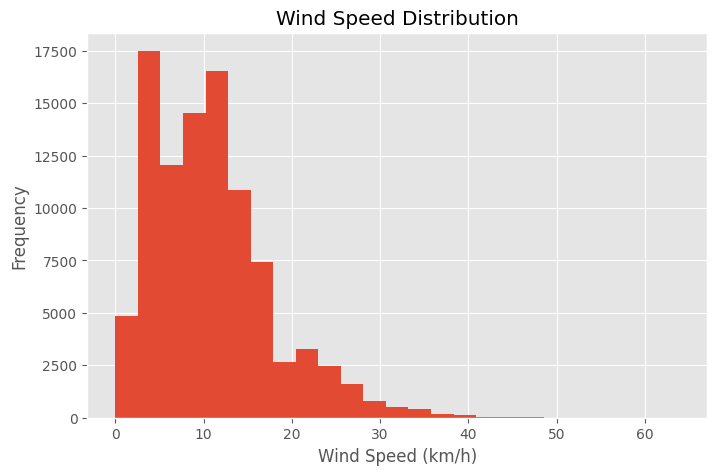

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Wind Speed (km/h)'],
    bins=25
)

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")

plt.show()

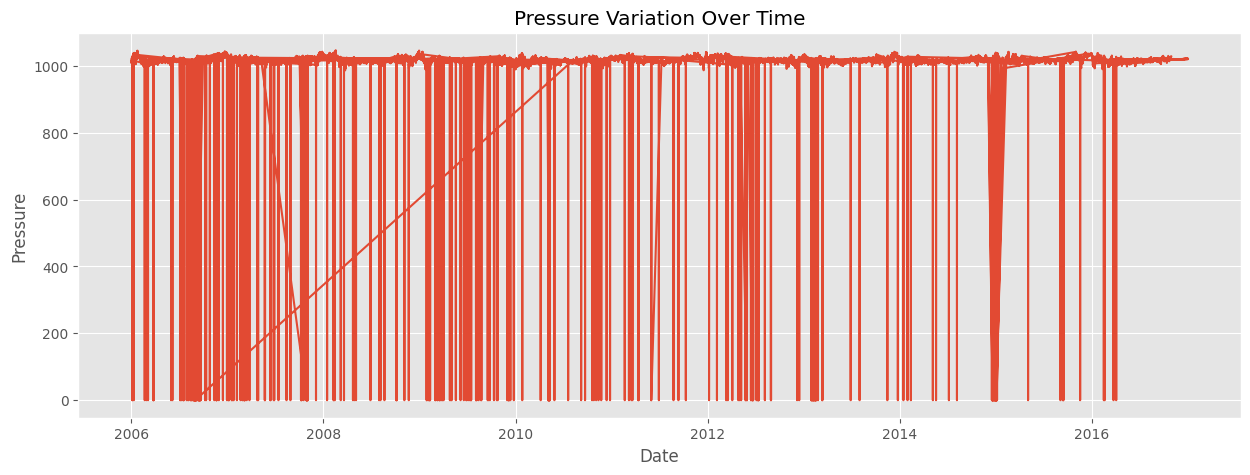

In [35]:
plt.figure(figsize=(15,5))

plt.plot(
    df['Formatted Date'],
    df['Pressure (millibars)']
)

plt.title("Pressure Variation Over Time")
plt.xlabel("Date")
plt.ylabel("Pressure")

plt.show()

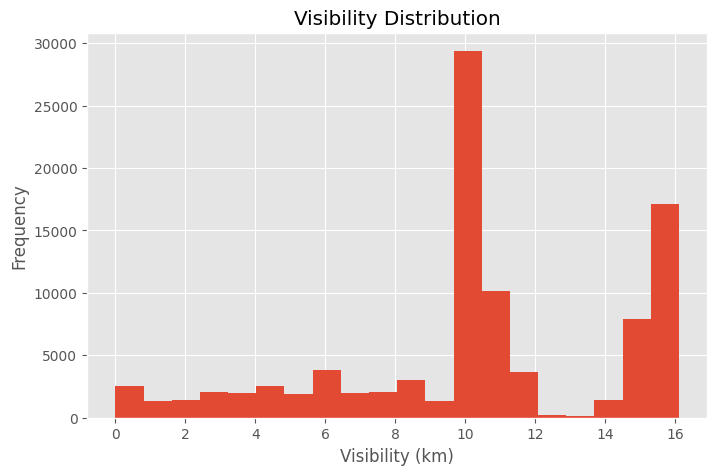

In [36]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Visibility (km)'],
    bins=20
)

plt.title("Visibility Distribution")
plt.xlabel("Visibility (km)")
plt.ylabel("Frequency")

plt.show()

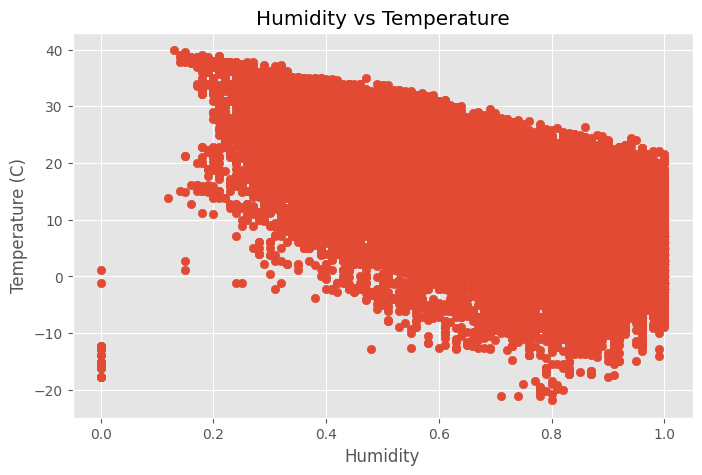

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Humidity'],
    df['Temperature (C)']
)

plt.title("Humidity vs Temperature")
plt.xlabel("Humidity")
plt.ylabel("Temperature (C)")

plt.show()

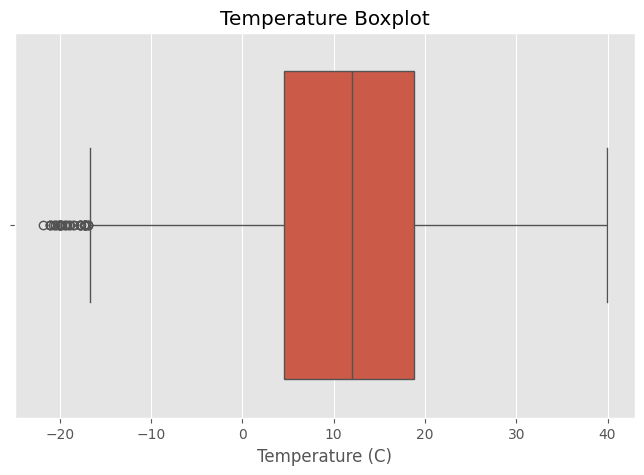

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Temperature (C)']
)

plt.title("Temperature Boxplot")

plt.show()

In [39]:
df['Summary'].value_counts().head(10)

Summary
Partly Cloudy               31628
Mostly Cloudy               27914
Overcast                    16516
Clear                       10746
Foggy                        7117
Breezy and Overcast           528
Breezy and Mostly Cloudy      516
Breezy and Partly Cloudy      386
Dry and Partly Cloudy          86
Windy and Partly Cloudy        67
Name: count, dtype: int64

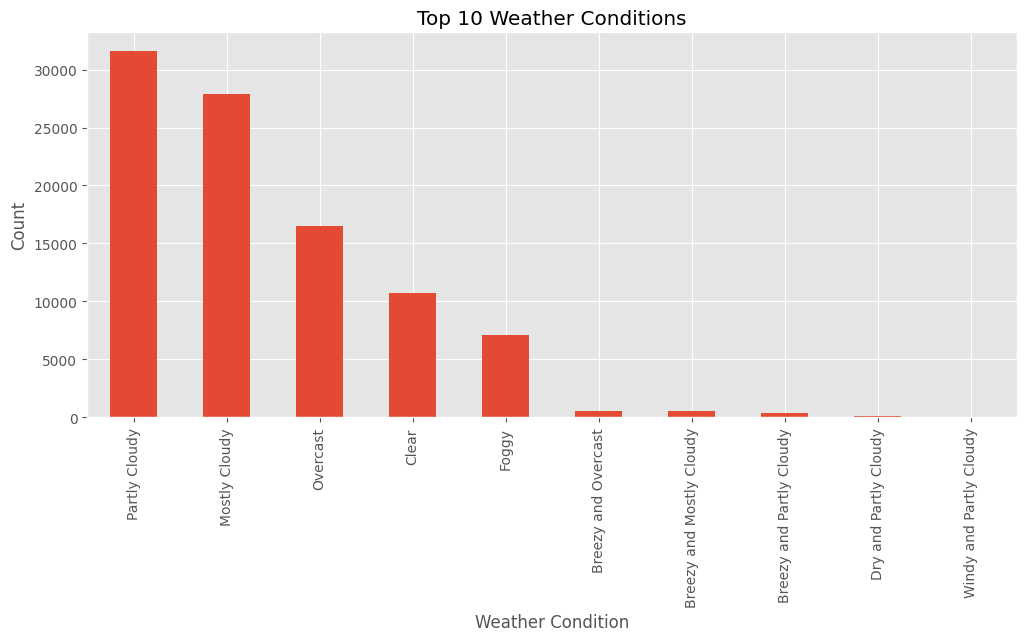

In [40]:
weather_counts = df['Summary'].value_counts().head(10)

weather_counts.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Count")

plt.show()

In [41]:
df['Daily Summary'].head()

0    Partly cloudy throughout the day.
1    Partly cloudy throughout the day.
2    Partly cloudy throughout the day.
3    Partly cloudy throughout the day.
4    Partly cloudy throughout the day.
Name: Daily Summary, dtype: str

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [43]:
X = df[[
    'Humidity',
    'Wind Speed (km/h)',
    'Pressure (millibars)',
    'Visibility (km)'
]]

In [44]:
y = df['Temperature (C)']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
predictions = model.predict(X_test)

In [48]:
print(
    "MAE:",
    mean_absolute_error(y_test, predictions)
)

print(
    "R2 Score:",
    r2_score(y_test, predictions)
)

MAE: 5.729877156779733
R2 Score: 0.4456391341901337


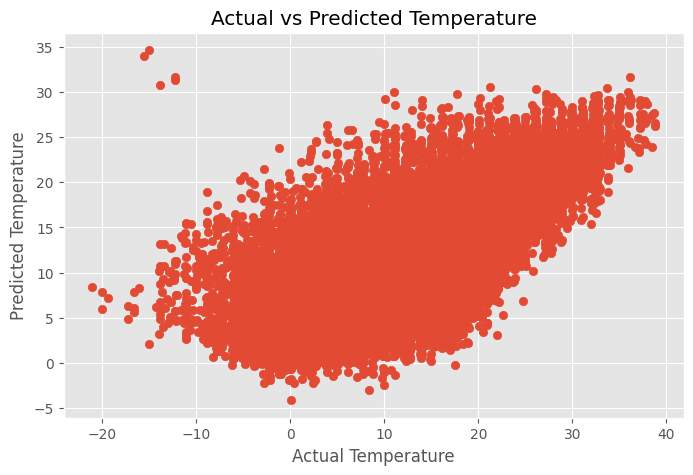

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("Actual vs Predicted Temperature")

plt.show()